# Proyek Analisis Sentimen

- Nama: Agil Firli Gunawan
- Email: agilfirli29@gmail.com
- Id Dicoding: agilfirligunawan

## Business Understanding

SeaBank merupakan salah satu bank digital di Indonesia yang memiliki banyak pengguna aktif. Review pengguna pada Google Play Store dapat digunakan untuk mengetahui tingkat kepuasan pengguna terhadap layanan aplikasi.

Analisis sentimen dilakukan untuk mengklasifikasikan opini pengguna ke dalam kategori positif, netral, dan negatif. Hasil analisis ini diharapkan dapat memberikan insight terhadap kualitas layanan aplikasi SeaBank.

### Import Library yang Digunakan

In [66]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from google_play_scraper import reviews, Sort

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from wordcloud import WordCloud

In [67]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### App ID SeaBank

In [68]:
app_id = 'id.co.bankbkemobile.digitalbank'

### Function Scraping

In [69]:
def scrape_reviews(app_id, total_reviews=10000):

    all_reviews = []

    continuation_token = None

    while len(all_reviews) < total_reviews:

        result, continuation_token = reviews(
            app_id,
            lang='id',
            country='id',
            sort=Sort.NEWEST,
            count=200,
            continuation_token=continuation_token
        )

        all_reviews.extend(result)

        print(f'Total review terkumpul: {len(all_reviews)}')

        if continuation_token is None:
            break

    return all_reviews[:total_reviews]

### Scraping Dataset

In [70]:
review_data = scrape_reviews(app_id, total_reviews=10000)

Total review terkumpul: 200
Total review terkumpul: 400
Total review terkumpul: 600
Total review terkumpul: 800
Total review terkumpul: 1000
Total review terkumpul: 1200
Total review terkumpul: 1400
Total review terkumpul: 1600
Total review terkumpul: 1800
Total review terkumpul: 2000
Total review terkumpul: 2200
Total review terkumpul: 2400
Total review terkumpul: 2600
Total review terkumpul: 2800
Total review terkumpul: 3000
Total review terkumpul: 3200
Total review terkumpul: 3400
Total review terkumpul: 3600
Total review terkumpul: 3800
Total review terkumpul: 4000
Total review terkumpul: 4200
Total review terkumpul: 4400
Total review terkumpul: 4600
Total review terkumpul: 4800
Total review terkumpul: 5000
Total review terkumpul: 5200
Total review terkumpul: 5400
Total review terkumpul: 5600
Total review terkumpul: 5800
Total review terkumpul: 6000
Total review terkumpul: 6200
Total review terkumpul: 6400
Total review terkumpul: 6600
Total review terkumpul: 6800
Total review terku

### Data Understanding

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   content  10000 non-null  object        
 1   score    10000 non-null  int64         
 2   at       10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 234.5+ KB


In [72]:
df.describe()

,score,at
count,10000.000000,10000
mean,4.523600,2026-04-28 12:54:53.833500160
min,1.000000,2026-04-12 09:04:53
25%,5.000000,2026-04-17 23:08:15.249999872
50%,5.000000,2026-04-29 04:39:22
75%,5.000000,2026-05-09 06:24:59.249999872
max,5.000000,2026-05-14 07:03:01
std,1.141216,NaN


### Convert Data Frame dan Ambil Kolom Penting

In [73]:
df = pd.DataFrame(review_data)
df = df[['content', 'score', 'at']]

### Rename Kolom

In [74]:
df.columns = ['review', 'rating', 'date']

### Cleaning Awal Dataset

In [76]:
df.dropna(inplace=True)

df.drop_duplicates(subset='review', inplace=True)

df.reset_index(drop=True, inplace=True)

### Labeling Sentimen dan Terapkan Labelling

In [77]:
def labeling(score):

    if score >= 4:
        return 'positif'

    elif score == 3:
        return 'netral'

    else:
        return 'negatif'


df['sentiment'] = df['rating'].apply(labeling)

### Distribusi Sentimen

sentiment
positif    4852
negatif     841
netral      221
Name: count, dtype: int64


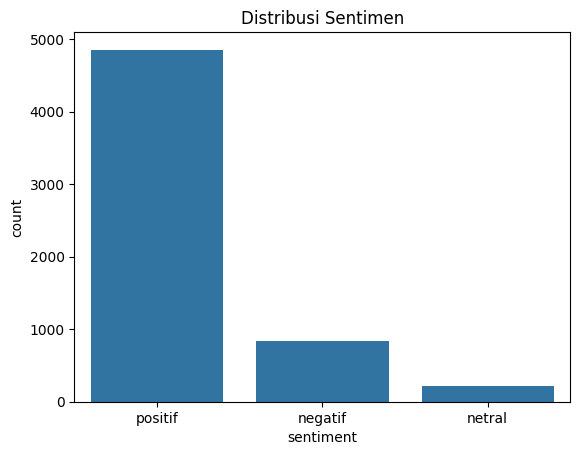

In [78]:
print(df['sentiment'].value_counts())

sns.countplot(x='sentiment', data=df)

plt.title('Distribusi Sentimen')

plt.show()

### Distribusi Rating

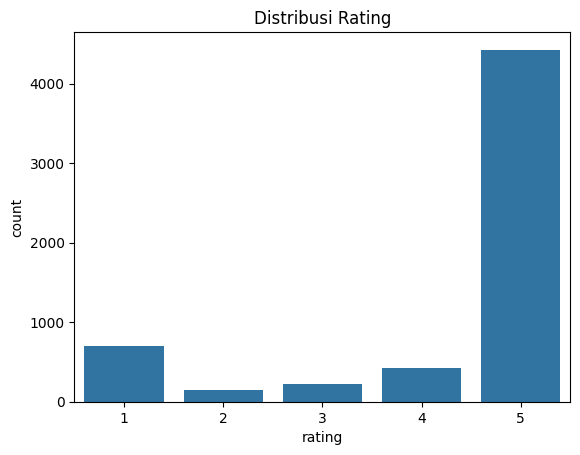

In [79]:
sns.countplot(x='rating', data=df)

plt.title('Distribusi Rating')

plt.show()

### Stopword Indonesia dan Stemmer Sastrawi

In [80]:
stop_words = set(stopwords.words('indonesian'))

factory = StemmerFactory()

stemmer = factory.create_stemmer()

### Function Cleaning Text

In [81]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#\w+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [stemmer.stem(word) for word in tokens]

    text = ' '.join(tokens)

    return text

### Preprocessing Text

In [82]:
df['clean_review'] = df['review'].apply(clean_text)

### Hasil Cleaning

In [83]:
df[['review', 'clean_review']].head()

,review,clean_review
0,kirim cepat saldo aman,kirim cepat saldo aman
1,luar biasa,
2,baik,
3,sangat berguna dan sangat murah dalam segala h...,guna murah terima kasih
4,mantap,mantap


### Feature dan Label

In [84]:
X = df['clean_review']

y = df['sentiment']

### Split Data

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### TF-IDF Vectorizer

In [86]:
tfidf = TfidfVectorizer(max_features=5000)

### Transform TF-IDF

In [87]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

### Logistic Regression dan Evaluasi Logistic Regression

In [88]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8850380388841927
              precision    recall  f1-score   support

     negatif       0.77      0.55      0.64       168
      netral       0.00      0.00      0.00        44
     positif       0.90      0.98      0.94       971

    accuracy                           0.89      1183
   macro avg       0.56      0.51      0.53      1183
weighted avg       0.85      0.89      0.86      1183



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Evaluasi SVM

In [89]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

Accuracy : 0.8951817413355875
              precision    recall  f1-score   support

     negatif       0.74      0.67      0.70       168
      netral       0.00      0.00      0.00        44
     positif       0.92      0.97      0.95       971

    accuracy                           0.90      1183
   macro avg       0.55      0.55      0.55      1183
weighted avg       0.86      0.90      0.88      1183



### Encoding Label

In [90]:
label_mapping = {
    'negatif':0,
    'netral':1,
    'positif':2
}

y_encoded = y.map(label_mapping)

### Split Data Deep Learning

In [91]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

### Tokenizer

In [93]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train_dl)

import pickle
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(
        tokenizer,
        handle,
        protocol=pickle.HIGHEST_PROTOCOL
    )

print("Tokenizer berhasil disimpan!")

Tokenizer berhasil disimpan!


### Text to Sequence

In [94]:
X_train_seq = tokenizer.texts_to_sequences(X_train_dl)

X_test_seq = tokenizer.texts_to_sequences(X_test_dl)

### Padding Sequence

In [95]:
X_train_pad = pad_sequences(X_train_seq, maxlen=100)

X_test_pad = pad_sequences(X_test_seq, maxlen=100)

### Build Model LSTM

In [96]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))

model.add(LSTM(128))

model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))

model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### Compile Model

In [97]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

### Early Stopping

In [98]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Training Model LSTM

In [99]:
history = model.fit(
    X_train_pad,
    y_train_dl,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 0.8285 - loss: 0.4979 - val_accuracy: 0.8648 - val_loss: 0.3735
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - accuracy: 0.8911 - loss: 0.3279 - val_accuracy: 0.8955 - val_loss: 0.3260
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.9154 - loss: 0.2478 - val_accuracy: 0.8976 - val_loss: 0.3314
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 23s 194ms/step - accuracy: 0.9294 - loss: 0.2087 - val_accuracy: 0.8902 - val_loss: 0.3606
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 184ms/step - accuracy: 0.9379 - loss: 0.1748 - val_accuracy: 0.8849 - val_loss: 0.3916


### Evaluasi Model LSTM

In [100]:
loss, accuracy = model.evaluate(X_test_pad, y_test_dl)

print("Accuracy :", accuracy)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8867 - loss: 0.3766
Accuracy : 0.8867286443710327


### Visualisasi Accuracy

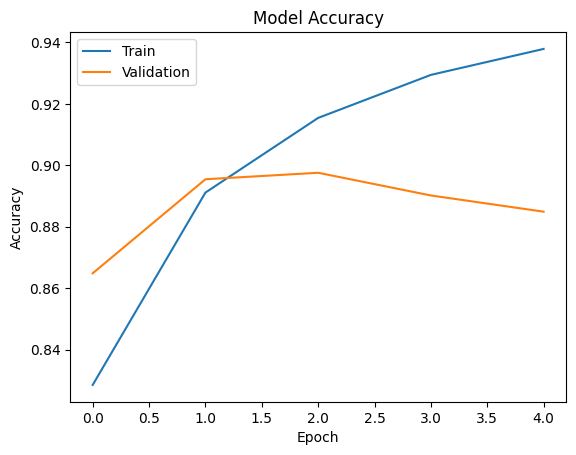

In [101]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

### Confusion Matrix

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step


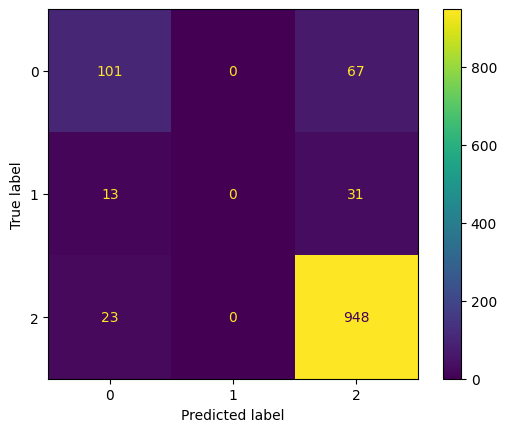

In [102]:
y_pred_dl = model.predict(X_test_pad)

y_pred_dl = np.argmax(y_pred_dl, axis=1)

cm = confusion_matrix(y_test_dl, y_pred_dl)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

### Perbandingan Accuracy Model

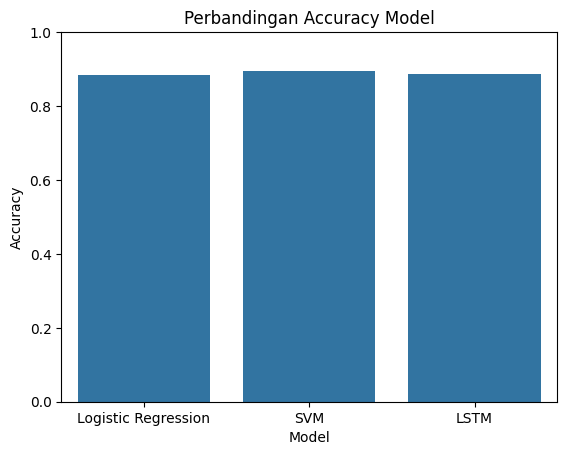

In [104]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'LSTM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy
    ]
})

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title('Perbandingan Accuracy Model')

plt.ylim(0,1)

plt.show()

### WordCloud Positif

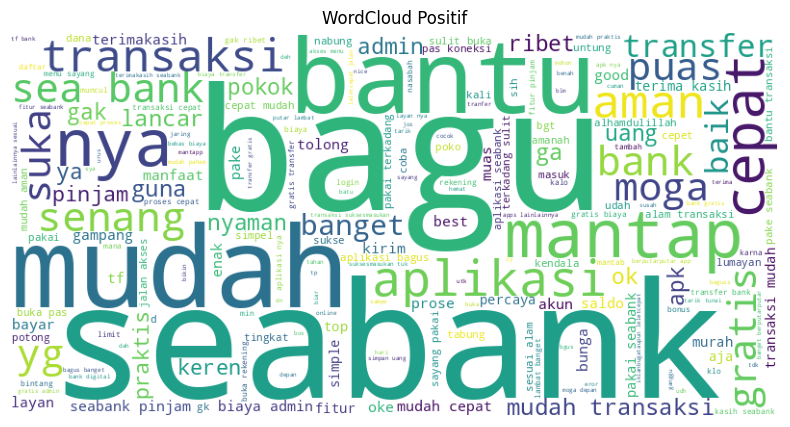

In [105]:
positive_text = ' '.join(
    df[df['sentiment'] == 'positif']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('WordCloud Positif')

plt.show()

### WordCloud Negatif

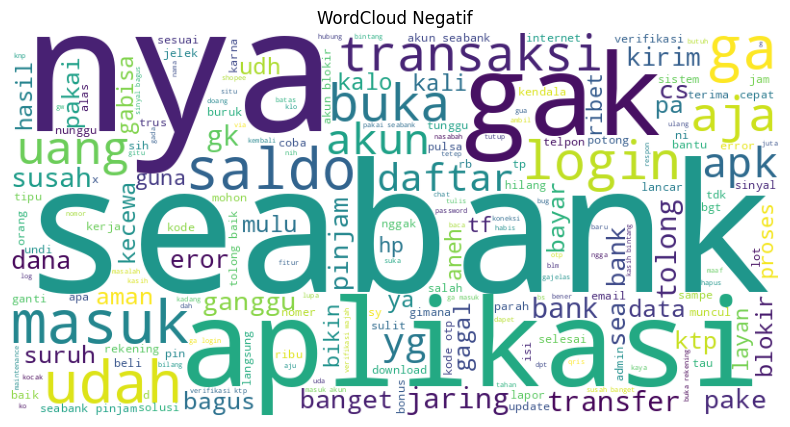

In [106]:
negative_text = ' '.join(
    df[df['sentiment'] == 'negatif']['clean_review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('WordCloud Negatif')

plt.show()

### Simpan Dataset

In [107]:
df.to_csv('seabank_reviews.csv', index=False)

### Simpan Model

In [108]:
model.save('model_lstm.h5')

### Inference / Prediksi Manual

In [109]:
text = "Aplikasi sangat membantu dan transfer cepat"

text_clean = clean_text(text)

text_seq = tokenizer.texts_to_sequences([text_clean])

text_pad = pad_sequences(text_seq, maxlen=100)

prediction = model.predict(text_pad)

predicted_label = np.argmax(prediction)

label_reverse = {
    0:'negatif',
    1:'netral',
    2:'positif'
}

print("Hasil Prediksi :", label_reverse[predicted_label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Hasil Prediksi : positif
